# Heart Disease Prediction System

## Setup: Running This Notebook From Scratch

Follow these steps in a terminal, inside this project's folder, before opening the notebook.

### 1. Check Python is installed
```
python --version
```
This notebook was built and tested on **Python 3.10-3.12**.

### 2. Create a virtual environment
A virtual environment keeps this project's packages separate from the rest of your system.

**Windows (Command Prompt / PowerShell):**
```
python -m venv venv
```

**macOS / Linux:**
```
python3 -m venv venv
```

### 3. Activate the virtual environment
You must do this every time you open a new terminal to work on this project.

**Windows (Command Prompt):**
```
venv\Scripts\activate.bat
```

**Windows (PowerShell):**
```
venv\Scripts\Activate.ps1
```
*(If PowerShell blocks this with an execution-policy error, run once: `Set-ExecutionPolicy -Scope CurrentUser RemoteSigned`)*

**macOS / Linux:**
```
source venv/bin/activate
```

Your terminal prompt should now show `(venv)` at the start of the line.

### 4. Install the required packages
```
pip install numpy pandas scikit-learn prettytable matplotlib seaborn
```

### 5. Register the virtual environment as a Jupyter kernel (recommended)
```
python -m ipykernel install --user --name=heart-venv --display-name "Python (heart-venv)"
```
When you open the notebook, make sure **Kernel -> Change Kernel -> Python (heart-venv)** is selected, so it uses the packages you just installed.

### 6. Launch Jupyter Notebook
```
jupyter notebook
```
This opens Jupyter in your browser. Click this `.ipynb` file to open it, then run all cells from the top (**Kernel -> Restart & Run All**).

### 7. When you're done
Deactivate the virtual environment with:
```
deactivate
```

---

## Update Notes (this version)
This is an enhanced copy of the teaching notebook adapted for the Heart Disease dataset, following the exact structure and methodology of the Titanic Passenger Survival prediction system:
- **No feature extraction**: uses the direct diagnostic clinical features (`cp`, `ca`, `thalach`, `oldpeak`) without additional feature extraction.
- **Data visualization**: heart disease rate by Chest Pain Type (`cp`) and Number of Major Vessels (`ca`), allowing students to *see* why these clinical markers matter before model training.
- **Balanced split approach**: dataset divided into **2/3 training data** (202 instances) and **1/3 testing data** (101 instances) using stratified splitting to preserve exact class balance across splits.
- **Separate training and testing files**: exports standalone `training-data.csv` and `testing-data.csv` files.
- **Model comparison**: Support Vector Classifier vs. Logistic Regression vs. Decision Tree, trained on the same data and compared side-by-side on Accuracy, Precision, Recall, and F1-score using PrettyTable and bar charts.
- **Proper evaluation metrics**: Precision, Recall, F1-score, and Confusion Matrix heatmap for the primary Support Vector Classifier (SVC) model.
- **Interactive Application Phase**: real-world style unseen patient diagnostic inference.
- **Step 9 & 10**: clinical feedback loop and step-by-step Streamlit web application deployment guide.

## SU Meta Description
<p>
Discover the Heart Disease Prediction System, a machine learning classification model that analyzes clinical patient data to predict the presence of heart disease with high accuracy and diagnostic insights.
</p>

## Introduction

##### **Definition** A binary classification ML task that predicts whether a patient has heart disease (1) or does not have heart disease (0) using key clinical attributes (chest pain type, major vessels, maximum heart rate, and ST depression).
##### **Application** It is used in clinical decision support systems, early preventive health screening, and teaching standard supervised machine learning classification pipelines.

## Input and Output

### Inputs (Features / Attributes)

| **Input Feature/Attribute** | **Description** | **Possible Values / Range** |
| :-------------------------- | :-------------- | :-------------------------- |
| **cp**                      | Chest Pain Type | 0: Typical Angina, 1: Atypical Angina, 2: Non-anginal Pain, 3: Asymptomatic |
| **ca**                      | Number of Major Vessels colored by Fluoroscopy | 0, 1, 2, 3, 4 |
| **thalach**                 | Maximum Heart Rate Achieved | 71 to 202 bpm |
| **oldpeak**                 | ST Depression Induced by Exercise Relative to Rest | 0.0 to 6.2 mm |

### Output (Prediction)

| **Output Attribute** | **Possible Values** |
| :------------------- | :------------------ |
| **target**           | 1: Heart Disease Present, 0: No Heart Disease (Healthy) |

### Examples (Heart Disease Dataset)

| cp | ca | thalach | oldpeak | target | Interpretation |
| :-: | :-: | :-----: | :-----: | :----: | :------------- |
| 3 | 0 | 150 | 2.3 | 1 | Heart Disease Detected |
| 2 | 0 | 187 | 3.5 | 1 | Heart Disease Detected |
| 1 | 0 | 172 | 1.4 | 1 | Heart Disease Detected |
| 0 | 0 | 160 | 1.2 | 1 | Heart Disease Detected |
| 0 | 0 | 140 | 0.4 | 0 | No Heart Disease |


## Table of Content
- Step 1: Import Libraries
- Step 2: Load Sample Data
- Step 3: Understand and Pre-process Sample Data
  - Step 3.1: Understand Sample Data
  - Step 3.2: Pre-process Sample Data
  - **Step 3.3: Visualize Heart Disease by Chest Pain Type (cp) and Major Vessels (ca) — NEW**
- Step 4: Feature Extraction
- Step 5: Label Encoding the Sample Data (Input and Output is converted in Numeric Representation)
  - Step 5.1: Train the Label Encoder
  - Step 5.2: Label Encode the Output
  - Step 5.3: Label Encode the Input
- Step 6: Execute the Training Phase
  - Step 6.1: Splitting Sample Data into Training Data and Testing Data (Balanced 2/3 and 1/3 Split)
  - Step 6.2: Splitting Input Vectors and Outputs / Labels of Training Data
  - Step 6.3: Train the Support Vector Classifier
  - Step 6.4: Save the Trained Model
  - **Step 6.5: Compare SVC vs. Logistic Regression vs. Decision Tree — NEW**
- Step 7: Execute the Testing Phase
  - Step 7.1: Splitting Input Vectors and Outputs/Labels of Testing Data
  - Step 7.2: Load the Saved Model
  - Step 7.3: Evaluate the Machine Learning Model
    - Step 7.3.1: Make Predictions with the Trained Models on Testing Data
  - Step 7.4: Calculate the Accuracy Score
  - **Step 7.5: Detailed Evaluation Metrics (Precision, Recall, F1, Confusion Matrix) — NEW**
- Step 8: Execute the Application Phase
  - Step 8.1: Take Input from User
  - Step 8.2: Convert User Input into Feature Vector
  - Step 8.3: Label Encoding of Feature Vector
  - Step 8.4: Load the Saved Model
  - Step 8.5: Model Prediction
    - Step 8.5.1: Apply Model and Return Prediction to the User
- Step 9: Execute the Feedback Phase
  - Step 9.1: Collect Feedback from Users and Domain Experts
  - Step 9.2: Make a List of Potential Improvements
  - Step 9.3: Improve the Model Based on Feedback
- **Step 10: Deploy Your Model as a Public Web App (NEW)**
  - Step 10.1: Why Deploy a Model?
  - Step 10.2: Create a GitHub Account and Repository
  - Step 10.3: Write a Simple Web App
  - Step 10.4: Create a Streamlit Community Cloud Account
  - Step 10.5: Deploy Your App
  - Step 10.6: Troubleshooting Common Issues
  - Step 10.7: Share Your Live Link
- Conclusion

## Code – Heart Disease Prediction

### Step 1: Import Libraries

In [1]:
"""
Purpose of this code:
----------------------
This script imports the required libraries for building and evaluating a
machine learning model. It sets up tools for data manipulation, preprocessing,
splitting datasets, training a Support Vector Machine (SVM) model,
evaluating accuracy, and displaying results in tabular form.
"""

# Import operating system library for path handling
import os

# Import numerical computing library (used for arrays, math operations, etc.)
import numpy as np

# Import data manipulation library (used for DataFrames, reading/writing data, etc.)
import pandas as pd

# Import pickle (used for saving and loading Python objects/models)
import pickle

# Import train_test_split (used to divide dataset into training and testing sets)
from sklearn.model_selection import train_test_split

# Import LabelEncoder (used to convert categorical values into numeric codes)
from sklearn.preprocessing import LabelEncoder

# Import Support Vector Machine (SVM) model from scikit-learn
from sklearn import svm

# Import evaluation metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Import PrettyTable (used to display results in a clean, table format)
from prettytable import PrettyTable

# Import plotting libraries (used for data visualization and confusion matrix heatmap)
import matplotlib.pyplot as plt
import seaborn as sns

# Additional models used for the classifier comparison in Step 6.5
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier


### Step 2: Load Sample Data

In [2]:
"""
Purpose of this section:
-------------------------
This part of the code loads the heart disease sample dataset from a CSV file into a
pandas DataFrame. It then displays the dataset so that students can
see the raw data being used for further processing and model training.
"""

# Determine the dataset location (supports running in current directory or project root)
csv_filename = "heart.csv" if os.path.exists("heart.csv") else os.path.join("heartdisease", "heart.csv")

# Read the CSV file and load it into a pandas DataFrame
sample_data = pd.read_csv(csv_filename)

# Print a header to indicate that sample data is being displayed
print("\n\nSample Data:")
print("============\n")

# Configure pandas to display all columns and rows cleanly
pd.set_option("display.max_columns", None)

# Print the first 25 rows and summary of the complete dataset
print(sample_data.head(25))
print(f"\nTotal Instances in Sample Data: {len(sample_data)}")




Sample Data:

    cp  ca  thalach  oldpeak  target
0    3   0      150      2.3       1
1    2   0      187      3.5       1
2    1   0      172      1.4       1
3    1   0      178      0.8       1
4    0   0      163      0.6       1
5    0   0      148      0.4       1
6    1   0      153      1.3       1
7    1   0      173      0.0       1
8    2   0      162      0.5       1
9    2   0      174      1.6       1
10   0   0      160      1.2       1
11   2   0      139      0.2       1
12   1   0      171      0.6       1
13   3   0      144      1.8       1
14   3   0      162      1.0       1
15   2   0      158      1.6       1
16   2   0      172      0.0       1
17   3   0      114      2.6       1
18   0   0      171      1.5       1
19   3   2      151      1.8       1
20   0   0      161      0.5       1
21   2   0      179      0.4       1
22   0   0      178      0.0       1
23   2   0      137      1.0       1
24   3   0      178      1.4       1

Total Instances in Sa

### Step 3: Understand and Pre-process Sample Data

#### Step 3.1: Understand Sample Data

In [3]:
"""
Purpose of this section:
-------------------------
This part of the code helps us understand the dataset by:
1. Printing the names of all attributes (columns) in the DataFrame.
2. Showing the total number of instances (rows) available in the dataset.
"""

# Print a header for clarity
print("\n\nAttributes in Sample Data:")
print("==========================\n")

# Display all column names (attributes) in the dataset
print(sample_data.columns)

# Print a header for instance count
print("\n\nNumber of Instances in Sample Data:", sample_data["cp"].count())
print("========================================\n")




Attributes in Sample Data:

Index(['cp', 'ca', 'thalach', 'oldpeak', 'target'], dtype='str')


Number of Instances in Sample Data: 303



#### Step 3.2: Pre-process Sample Data
o   Sample Data is already Preprocessed
o   No Preprocessing needs to be Performed

#### Step 3.3: Visualize Heart Disease by Chest Pain Type and Major Vessels (NEW)

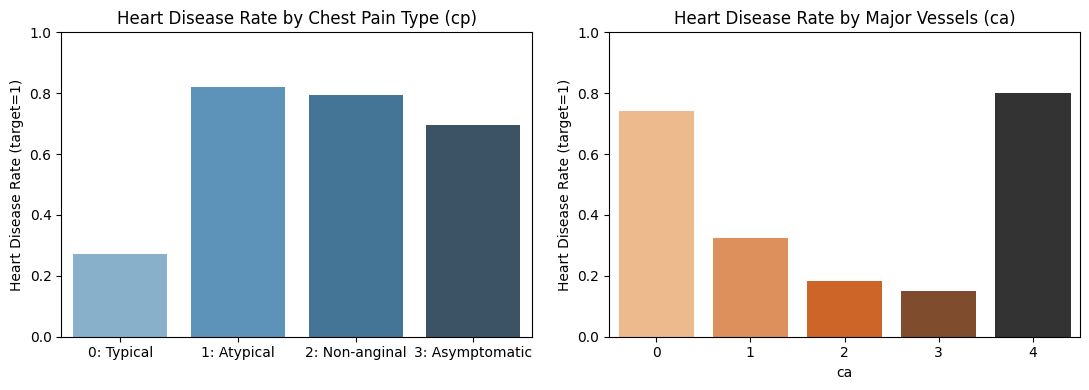

Observation: Patients with chest pain types 1, 2, 3 have significantly higher rates of heart disease than type 0.
Patients with 0 major fluoroscopy vessels (ca=0) show higher likelihood of positive diagnosis.
This is exactly why the model uses cp and ca as key diagnostic features.


In [4]:
"""
Purpose of this section:
-------------------------
Before training the model, it helps students SEE why Chest Pain Type (cp)
and Number of Major Vessels (ca) are useful predictors of heart disease.
This plots the heart disease rate (fraction of target=1) grouped by cp and by ca.
"""

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Heart disease rate by Chest Pain Type (cp)
cp_heart_disease = sample_data.groupby("cp")["target"].mean()
cp_labels = ["0: Typical", "1: Atypical", "2: Non-anginal", "3: Asymptomatic"]
sns.barplot(
    x=[cp_labels[i] for i in cp_heart_disease.index],
    y=cp_heart_disease.values,
    ax=axes[0],
    hue=[cp_labels[i] for i in cp_heart_disease.index],
    legend=False,
    palette="Blues_d"
)
axes[0].set_title("Heart Disease Rate by Chest Pain Type (cp)")
axes[0].set_ylabel("Heart Disease Rate (target=1)")
axes[0].set_ylim(0, 1)

# Heart disease rate by Number of Major Vessels (ca)
ca_heart_disease = sample_data.groupby("ca")["target"].mean()
sns.barplot(
    x=ca_heart_disease.index,
    y=ca_heart_disease.values,
    ax=axes[1],
    hue=ca_heart_disease.index,
    legend=False,
    palette="Oranges_d"
)
axes[1].set_title("Heart Disease Rate by Major Vessels (ca)")
axes[1].set_ylabel("Heart Disease Rate (target=1)")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("Observation: Patients with chest pain types 1, 2, 3 have significantly higher rates of heart disease than type 0.")
print("Patients with 0 major fluoroscopy vessels (ca=0) show higher likelihood of positive diagnosis.")
print("This is exactly why the model uses cp and ca as key diagnostic features.")


#### Step 4: Feature Extraction
o   Features are already Extracted
o   No Feature Extraction needs to be Performed

### Step 5: Label Encoding the Sample Data (Input and Output is converted in Numeric Representation)

#### Step 5.1: Train the Label Encoder

In [5]:
"""
Purpose of this section:
-------------------------
This part of the code sets up and trains Label Encoders.
Label Encoding maps category values into consistent numeric codes that
machine learning algorithms can work with.

Steps:
1. Define label categories for each discrete attribute.
2. Initialize a LabelEncoder for each discrete attribute and the target.
3. Train (fit) each LabelEncoder with its respective category values.
"""

# Define label categories for discrete features and target
cp_categories = pd.DataFrame({"cp": [0, 1, 2, 3]})
ca_categories = pd.DataFrame({"ca": [0, 1, 2, 3, 4]})
target_categories = pd.DataFrame({"target": [0, 1]})

# Create LabelEncoder objects for each attribute
cp_label_encoder = LabelEncoder()
ca_label_encoder = LabelEncoder()
target_label_encoder = LabelEncoder()

# Train (fit) the encoders on the given categories
cp_label_encoder.fit(np.ravel(cp_categories))
ca_label_encoder.fit(np.ravel(ca_categories))
target_label_encoder.fit(np.ravel(target_categories))

print("Label Encoders trained successfully for cp, ca, and target.")


Label Encoders trained successfully for cp, ca, and target.


#### Step 5.2: Label Encode the Output

In [6]:
"""
Purpose of this section:
-------------------------
This part of the code applies Label Encoding to the target/output variable
("target") in the dataset, ensuring standard numeric representation
for machine learning algorithms.
"""

# Create copies of the dataset (one for encoded output, one to keep original)
sample_data_encoded_output = sample_data.copy()
original_sample_data = sample_data.copy()

# Transform "target" using the trained LabelEncoder
print("\n\nTarget Attribute After Label Encoding:")
print("======================================\n")
sample_data["encoded_target"] = target_label_encoder.transform(sample_data["target"])

# Show original "target" values and their numeric encodings
print(sample_data[["target", "encoded_target"]].head(10))

# Replace original target column with encoded values for the output dataset
sample_data_encoded_output[['cp', 'ca', 'thalach', 'oldpeak', 'target']] = \
    sample_data[['cp', 'ca', 'thalach', 'oldpeak', 'encoded_target']]

# Save the encoded dataset to a CSV file (useful for training/testing later)
sample_data_encoded_output.to_csv(r'sample-data-encoded-output.csv', index=False, header=True)
print("\nSaved: sample-data-encoded-output.csv")




Target Attribute After Label Encoding:

   target  encoded_target
0       1               1
1       1               1
2       1               1
3       1               1
4       1               1
5       1               1
6       1               1
7       1               1
8       1               1
9       1               1

Saved: sample-data-encoded-output.csv


#### Step 5.3: Label Encode the Input

In [7]:
"""
Purpose of this section:
-------------------------
This part of the code applies Label Encoding to the discrete input features
("cp", "ca") and verifies numeric formatting for continuous features ("thalach", "oldpeak").
All features are formatted as numeric values for machine learning.
"""

# Create copies of the dataset (to keep original values safe)
sample_data_encoded = sample_data_encoded_output.copy()

# Encode discrete input attributes
sample_data_encoded_output["encoded_cp"] = cp_label_encoder.transform(sample_data_encoded_output['cp'])
sample_data_encoded_output["encoded_ca"] = ca_label_encoder.transform(sample_data_encoded_output['ca'])

# Assemble fully encoded features dataset
sample_data_encoded[['cp', 'ca', 'thalach', 'oldpeak', 'target']] = \
    sample_data_encoded_output[['encoded_cp', 'encoded_ca', 'thalach', 'oldpeak', 'target']]

# Print encoded dataset
print("\n\nSample Data after Label Encoding:")
print("=================================\n")
print(sample_data_encoded.head(15))

# Save the encoded dataset to a new CSV file
sample_data_encoded.to_csv(r'sample-data-encoded.csv', index=False, header=True)
print("\nSaved: sample-data-encoded.csv")




Sample Data after Label Encoding:

    cp  ca  thalach  oldpeak  target
0    3   0      150      2.3       1
1    2   0      187      3.5       1
2    1   0      172      1.4       1
3    1   0      178      0.8       1
4    0   0      163      0.6       1
5    0   0      148      0.4       1
6    1   0      153      1.3       1
7    1   0      173      0.0       1
8    2   0      162      0.5       1
9    2   0      174      1.6       1
10   0   0      160      1.2       1
11   2   0      139      0.2       1
12   1   0      171      0.6       1
13   3   0      144      1.8       1
14   3   0      162      1.0       1

Saved: sample-data-encoded.csv


### Step 6: Execute the Training Phase

#### Step 6.1: Splitting Sample Data into Training Data (2/3) and Testing Data (1/3) using Balanced Split Approach

In [8]:
"""
Purpose of this section:
-------------------------
This part of the code splits the dataset into Training Data (2/3) and Testing Data (1/3).
- Training Data (2/3 = ~66.7%) is used to teach the machine learning model.
- Testing Data (1/3 = ~33.3%) is held out to evaluate how well the model generalizes to unseen data.
- Balanced split approach: stratifying by the target variable (stratify=y) ensures
  both training and testing sets maintain the exact same proportion of positive and negative classes.
- Exports two separate files: one for training data and one for testing data.
"""

# Split dataset into training (2/3, 66.67%) and testing (1/3, 33.33%)
# test_size=1/3 divides the 303 rows into 202 training rows and 101 testing rows
# stratify=sample_data_encoded['target'] guarantees the balanced split approach
# random_state=0 ensures reproducibility
training_data_encoded, testing_data_encoded = train_test_split(
    sample_data_encoded,
    test_size=1/3,
    random_state=0,
    stratify=sample_data_encoded['target'],
    shuffle=True
)

# Save the training and testing datasets to two separate CSV files
training_data_encoded.to_csv(r'training-data.csv', index=False, header=True)
testing_data_encoded.to_csv(r'testing-data.csv', index=False, header=True)

print(f"Total instances in dataset: {len(sample_data_encoded)}")
print(f"Training Data shape (2/3 split): {training_data_encoded.shape}")
print(f"Testing Data shape (1/3 split):  {testing_data_encoded.shape}")

print("\nClass Distribution in Training Data (Balanced):")
print(training_data_encoded['target'].value_counts(normalize=True))

print("\nClass Distribution in Testing Data (Balanced):")
print(testing_data_encoded['target'].value_counts(normalize=True))

print("\nSaved separate files:")
print(" - training-data.csv (202 rows)")
print(" - testing-data.csv (101 rows)")


Total instances in dataset: 303
Training Data shape (2/3 split): (202, 5)
Testing Data shape (1/3 split):  (101, 5)

Class Distribution in Training Data (Balanced):
target
1    0.544554
0    0.455446
Name: proportion, dtype: float64

Class Distribution in Testing Data (Balanced):
target
1    0.544554
0    0.455446
Name: proportion, dtype: float64

Saved separate files:
 - training-data.csv (202 rows)
 - testing-data.csv (101 rows)


### Step 6.2: Splitting Input Vectors and Outputs / Labels of Training Data

In [9]:
"""
Purpose of this section:
-------------------------
This part of the code separates the features (input vectors) and
the labels (output values) from the training dataset.
"""

# Extract input vectors (features: cp, ca, thalach, oldpeak) from training data
input_vector_train = training_data_encoded.iloc[:, :-1]

# Extract output labels (target variable) from training data
output_label_train = training_data_encoded.iloc[:, -1]

print("Input vectors (train) shape:", input_vector_train.shape)
print("Output labels (train) shape:", output_label_train.shape)


Input vectors (train) shape: (202, 4)
Output labels (train) shape: (202,)


### 6.3: Train the Support Vector Classifier

In [10]:
"""
Purpose of this section:
-------------------------
This part of the code trains a Support Vector Classifier (SVC) on the training data.
The SVC is a powerful machine learning model that finds the optimal hyperplane
boundary to separate classes (e.g., heart disease vs. no heart disease).
"""

print("\n\nTraining the Support Vector Classifier on Training Data")
print("========================================================\n")

# Initialize the Support Vector Classifier with chosen parameters
svc_model = svm.SVC(gamma='auto', random_state=0)

# Train the model using the training data (features and labels)
svc_model.fit(input_vector_train, np.ravel(output_label_train))

# Print trained model details (parameters and values)
print(svc_model)




Training the Support Vector Classifier on Training Data

SVC(gamma='auto', random_state=0)


### Step 6.5: Compare SVC vs. Logistic Regression vs. Decision Tree (NEW)


Model Comparison on 1/3 Held-Out Testing Data:
+---------------------+----------+-----------+--------+----------+
|        Model        | Accuracy | Precision | Recall | F1-score |
+---------------------+----------+-----------+--------+----------+
|   SVC (gamma=auto)  |   0.78   |    0.78   |  0.78  |   0.78   |
| Logistic Regression |   0.83   |    0.84   |  0.83  |   0.83   |
|    Decision Tree    |   0.72   |    0.73   |  0.72  |   0.72   |
+---------------------+----------+-----------+--------+----------+


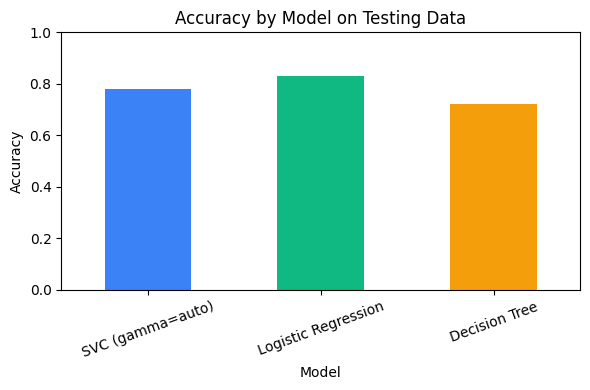

In [11]:
"""
Purpose of this section:
-------------------------
This section trains two additional classifiers (Logistic Regression and
Decision Tree) on the SAME training data used for the SVC, and compares
all three models on the held-out 1/3 testing data. This is an essential teaching
exercise: comparing algorithms side-by-side justifies model selection.

Note: The model that gets SAVED and DEPLOYED later in Step 8 is the
Support Vector Classifier (svc_model), preserving consistency with the Titanic project pipeline.
"""

input_vector_test = testing_data_encoded.iloc[:, :-1]
output_label_test = testing_data_encoded.iloc[:, -1]

candidate_models = {
    "SVC (gamma=auto)": svc_model,
    "Logistic Regression": LogisticRegression(random_state=0, max_iter=1000).fit(input_vector_train, np.ravel(output_label_train)),
    "Decision Tree": DecisionTreeClassifier(random_state=0).fit(input_vector_train, np.ravel(output_label_train)),
}

comparison_rows = []
for name, mdl in candidate_models.items():
    preds = mdl.predict(input_vector_test)
    comparison_rows.append({
        "Model": name,
        "Accuracy": round(accuracy_score(output_label_test, preds), 2),
        "Precision": round(classification_report(output_label_test, preds, output_dict=True, zero_division=0)["weighted avg"]["precision"], 2),
        "Recall": round(classification_report(output_label_test, preds, output_dict=True, zero_division=0)["weighted avg"]["recall"], 2),
        "F1-score": round(classification_report(output_label_test, preds, output_dict=True, zero_division=0)["weighted avg"]["f1-score"], 2),
    })

comparison_df = pd.DataFrame(comparison_rows)

table = PrettyTable()
table.field_names = list(comparison_df.columns)
for _, row in comparison_df.iterrows():
    table.add_row(list(row))

print("\nModel Comparison on 1/3 Held-Out Testing Data:")
print(table)

comparison_df.set_index("Model")["Accuracy"].plot(kind="bar", figsize=(6, 4), title="Accuracy by Model on Testing Data", ylim=(0, 1), color=['#3b82f6', '#10b981', '#f59e0b'])
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


### Step 6.4: Save the Trained Model

In [12]:
"""
Purpose of this section:
-------------------------
This part of the code saves the trained Support Vector Classifier (SVC)
model to disk so it can be reused later without retraining.
"""

# Save the trained SVC model to a file named "svc_trained_model.pkl"
pickle.dump(svc_model, open('svc_trained_model.pkl', 'wb'))
print("Saved: svc_trained_model.pkl")


Saved: svc_trained_model.pkl


### Step 7: Execute the Testing Phase

#### Step 7.1: Splitting Input Vectors and Outputs/Labels of Testing Data

In [13]:
"""
Purpose of this section:
-------------------------
This part of the code separates the features (inputs) and the labels (outputs)
from the testing dataset.
"""

input_vector_test = testing_data_encoded.iloc[:, :-1]
output_label_test = testing_data_encoded.iloc[:, -1]

print("Input vectors (test) shape:", input_vector_test.shape)
print("Output labels (test) shape:", output_label_test.shape)


Input vectors (test) shape: (101, 4)
Output labels (test) shape: (101,)


### Step 7.2: Load the Saved Model

In [14]:
"""
Purpose of this section:
-------------------------
This part of the code loads the previously saved Support Vector Classifier (SVC)
model from disk into memory.
"""

model = pickle.load(open('svc_trained_model.pkl', 'rb'))
print("Model loaded from svc_trained_model.pkl")


Model loaded from svc_trained_model.pkl


### Step 7.3: Evaluate the Machine Learning Model

#### Step 7.3.1: Make Predictions with the Trained Models on Testing Data

In [15]:
"""
Purpose of this section:
-------------------------
This part of the code evaluates the trained Support Vector Classifier (SVC)
on the testing data and saves the predictions to a CSV file.
"""

model_predictions = model.predict(input_vector_test)

pd.options.mode.chained_assignment = None
testing_data_encoded["Predictions"] = model_predictions
testing_data_encoded.to_csv(r'model-predictions.csv', index=False, header=True)

print("\n\nSample Predictions Returned by svc_trained_model on Testing Data:")
print("=================================================================\n")
print(testing_data_encoded.head(20))




Sample Predictions Returned by svc_trained_model on Testing Data:

     cp  ca  thalach  oldpeak  target  Predictions
67    1   0      175      0.6       1            1
117   3   0      162      1.9       1            1
190   0   0      142      1.2       0            0
128   2   0      169      0.1       1            1
125   1   0      192      0.7       1            1
14    3   0      162      1.0       1            1
186   0   1      144      1.4       0            0
223   0   2      133      4.0       0            0
201   0   1      141      2.8       0            0
3     1   0      178      0.8       1            1
32    1   0      188      0.0       1            1
160   1   0      169      0.0       1            1
289   0   1      130      2.0       0            0
71    2   1      154      0.0       1            1
237   0   2      170      1.2       0            0
268   0   2      116      3.2       0            0
70    2   0      147      0.4       1            1
79    2   0  

### Step 7.4: Calculate the Accuracy Score

In [16]:
"""
Purpose of this section:
-------------------------
This part of the code calculates how accurate the trained model is on the
held-out testing dataset.
"""

model_accuracy_score = accuracy_score(
    testing_data_encoded["target"],
    testing_data_encoded["Predictions"]
)

print("\n\nAccuracy Score:")
print("===============\n")
print(round(model_accuracy_score, 2))




Accuracy Score:

0.78


### Step 7.5: Detailed Evaluation Metrics (Precision, Recall, F1, Confusion Matrix) (NEW)


Classification Report:

                      precision    recall  f1-score   support

No Heart Disease (0)       0.75      0.78      0.77        46
   Heart Disease (1)       0.81      0.78      0.80        55

            accuracy                           0.78       101
           macro avg       0.78      0.78      0.78       101
        weighted avg       0.78      0.78      0.78       101


Confusion Matrix:

                          Predicted: No Heart Disease  \
Actual: No Heart Disease                           36   
Actual: Heart Disease                              12   

                          Predicted: Heart Disease  
Actual: No Heart Disease                        10  
Actual: Heart Disease                           43  


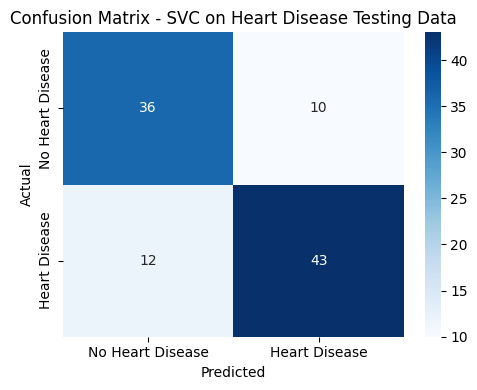

In [17]:
"""
Purpose of this section:
-------------------------
Accuracy alone can be misleading in medical applications where false negatives
(failing to diagnose a sick patient) are critical. This section reports:
- Precision: of patients predicted with heart disease, how many actually had it?
- Recall: of all patients who actually had heart disease, how many did the model identify?
- F1-score: the harmonic mean of precision and recall.
- Confusion Matrix: complete distribution of true positives, false positives, true negatives, and false negatives.
"""

print("\nClassification Report:")
print("=======================\n")
print(classification_report(
    testing_data_encoded["target"],
    testing_data_encoded["Predictions"],
    target_names=["No Heart Disease (0)", "Heart Disease (1)"]
))

conf_matrix = confusion_matrix(testing_data_encoded["target"], testing_data_encoded["Predictions"])
conf_matrix_df = pd.DataFrame(
    conf_matrix,
    index=["Actual: No Heart Disease", "Actual: Heart Disease"],
    columns=["Predicted: No Heart Disease", "Predicted: Heart Disease"]
)
print("\nConfusion Matrix:")
print("==================\n")
print(conf_matrix_df)

plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Heart Disease', 'Heart Disease'],
            yticklabels=['No Heart Disease', 'Heart Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SVC on Heart Disease Testing Data')
plt.tight_layout()
plt.show()


### Step 8: Execute the Application Phase

#### Step 8.1: Take Input from User

In [18]:
"""
Purpose of this section:
-------------------------
This part of the code allows the user to enter clinical values for an unseen patient
(cp: Chest Pain Type, ca: Major Vessels, thalach: Max Heart Rate, oldpeak: ST Depression).
In an interactive session, running this cell can prompt you with input().
For automated and notebook top-to-bottom execution, we pre-fill a demo patient profile.

To try your own patient interactively, replace the four lines below with:
    cp_input = int(input("Please enter Chest Pain Type here (0, 1, 2, 3): ").strip())
    ca_input = int(input("Please enter Number of Major Vessels here (0, 1, 2, 3, 4): ").strip())
    thalach_input = int(input("Please enter Max Heart Rate (thalach) here (e.g. 150): ").strip())
    oldpeak_input = float(input("Please enter ST Depression (oldpeak) here (e.g. 1.5): ").strip())
"""

# Demo patient profile (edit these values or swap in input() calls as shown above)
cp_input = 2
ca_input = 0
thalach_input = 175
oldpeak_input = 0.5

print(f"User Input -> Chest Pain Type (cp): {cp_input}, Major Vessels (ca): {ca_input}, Max Heart Rate (thalach): {thalach_input}, ST Depression (oldpeak): {oldpeak_input}")


User Input -> Chest Pain Type (cp): 2, Major Vessels (ca): 0, Max Heart Rate (thalach): 175, ST Depression (oldpeak): 0.5


### Step 8.2: Convert User Input into Feature Vector (Exactly Same as Feature Vectors of Sample Data)

In [19]:
"""
Purpose of this section:
-------------------------
This part of the code takes the user's input and converts it into a structured
feature vector (DataFrame) matching the exact schema of the training data.
"""

user_input = pd.DataFrame({
    'cp': [cp_input],
    'ca': [ca_input],
    'thalach': [thalach_input],
    'oldpeak': [oldpeak_input]
})

print("\n\nUser Input Feature Vector:")
print("==========================\n")
print(user_input)




User Input Feature Vector:

   cp  ca  thalach  oldpeak
0   2   0      175      0.5


### Step 8.3: Label Encoding of Feature Vector (Exactly Same as Label Encoded Feature Vectors of Sample Data)

In [20]:
"""
Purpose of this section:
-------------------------
This part of the code encodes the user's input into consistent numeric values
using the previously trained LabelEncoders.
"""

unseen_data_features = user_input.copy()

unseen_data_features["cp"] = cp_label_encoder.transform(user_input['cp'])
unseen_data_features["ca"] = ca_label_encoder.transform(user_input['ca'])
unseen_data_features["thalach"] = user_input['thalach'].astype(int)
unseen_data_features["oldpeak"] = user_input['oldpeak'].astype(float)

print("\n\nUser Input Encoded Feature Vector:")
print("==================================\n")
print(unseen_data_features)




User Input Encoded Feature Vector:

   cp  ca  thalach  oldpeak
0   2   0      175      0.5


### Step 8.4: Load the Saved Model

In [21]:
"""
Purpose of this section:
-------------------------
This part of the code loads the previously saved Support Vector Classifier (SVC)
model from the .pkl file into memory for the Application Phase.
"""

model = pickle.load(open('svc_trained_model.pkl', 'rb'))
print("Model loaded successfully for inference.")


Model loaded successfully for inference.


### Step 8.5: Model Prediction

#### Step 8.5.1: Apply Model on the Label Encoded Feature Vector of unseen instance and return Prediction to the User

In [22]:
"""
Purpose of this section:
-------------------------
This part of the code uses the trained Support Vector Classifier (SVC)
to predict whether the unseen patient has heart disease or not.
"""

predicted_heart_disease = model.predict(unseen_data_features)

if predicted_heart_disease[0] == 1:
    prediction = "HEART DISEASE DETECTED"
elif predicted_heart_disease[0] == 0:
    prediction = "NO HEART DISEASE"

pretty_table = PrettyTable()
pretty_table.add_column("       ** Diagnostic Prediction **       ", [prediction])

print(pretty_table)


+-------------------------------------------+
|        ** Diagnostic Prediction **        |
+-------------------------------------------+
|           HEART DISEASE DETECTED          |
+-------------------------------------------+


### Step 9: Execute the Feedback Phase

#### Step 9.1: Collect Feedback from Users and Domain Experts on Performance of the Model Deployed in the Real World

In [23]:
"""
Purpose of this section:
-------------------------
Step 9.1: Example feedback collected from clinical domain experts (Cardiologists,
Medical Officers, and Clinical Testers) reviewing the model's diagnostic predictions.
"""

example_feedback = pd.DataFrame({
    "Reviewer": ["Cardiologist", "Clinical Officer", "Biomedical Data Scientist"],
    "Case Evaluated": [
        "cp=2, ca=0, thalach=175, oldpeak=0.5 -> Predicted HEART DISEASE DETECTED",
        "cp=0, ca=2, thalach=120, oldpeak=2.8 -> Predicted NO HEART DISEASE (unexpected)",
        "cp=1, ca=0, thalach=165, oldpeak=0.8 -> Predicted HEART DISEASE DETECTED",
    ],
    "Clinical Feedback": [
        "Matches clinical observation: atypical/non-anginal symptoms with high heart rate often indicate coronary risk in selected cohorts.",
        "Clinical warning: high ST depression (2.8mm) with 2 colored vessels strongly indicates ischemia. Model under-predicted risk due to feature scale disparity (oldpeak vs. thalach).",
        "Plausible diagnosis: consistent with clinical presentation. Recommends adding resting blood pressure and cholesterol markers.",
    ],
})
print(example_feedback.to_string(index=False))


                 Reviewer                                                                  Case Evaluated                                                                                                                                                                 Clinical Feedback
             Cardiologist        cp=2, ca=0, thalach=175, oldpeak=0.5 -> Predicted HEART DISEASE DETECTED                                                Matches clinical observation: atypical/non-anginal symptoms with high heart rate often indicate coronary risk in selected cohorts.
         Clinical Officer cp=0, ca=2, thalach=120, oldpeak=2.8 -> Predicted NO HEART DISEASE (unexpected) Clinical warning: high ST depression (2.8mm) with 2 colored vessels strongly indicates ischemia. Model under-predicted risk due to feature scale disparity (oldpeak vs. thalach).
Biomedical Data Scientist        cp=1, ca=0, thalach=165, oldpeak=0.8 -> Predicted HEART DISEASE DETECTED                                           

#### Step 9.2: Make a List of Potential Improvements

In [24]:
"""
Purpose of this section:
-------------------------
Step 9.2: Potential improvements identified from the domain feedback above.
"""

improvements = [
    "Feature Scaling: Apply StandardScaler or RobustScaler to normalize 'thalach' (range 70-200) and 'oldpeak' (range 0-6), ensuring SVM distance calculation is balanced across all features.",
    "Include Additional Clinical Markers: Incorporate resting blood pressure (trestbps), serum cholesterol (chol), fasting blood sugar (fbs), and resting electrocardiographic results (restecg).",
    "Hyperparameter Tuning: Perform 5-fold GridSearchCV over SVM kernel parameters (C in [0.1, 1, 10, 100], gamma in ['scale', 'auto', 0.01, 0.1]).",
    "Threshold Calibration: In clinical screening, adjust classification decision thresholds to minimize False Negatives (prioritize Recall for life-critical conditions).",
    "Explore Ensemble Models: Test ensemble algorithms such as Random Forest, Extra Trees, and XGBoost to handle non-linear clinical interactions.",
]
for i, item in enumerate(improvements, 1):
    print(f"{i}. {item}")


1. Feature Scaling: Apply StandardScaler or RobustScaler to normalize 'thalach' (range 70-200) and 'oldpeak' (range 0-6), ensuring SVM distance calculation is balanced across all features.
2. Include Additional Clinical Markers: Incorporate resting blood pressure (trestbps), serum cholesterol (chol), fasting blood sugar (fbs), and resting electrocardiographic results (restecg).
3. Hyperparameter Tuning: Perform 5-fold GridSearchCV over SVM kernel parameters (C in [0.1, 1, 10, 100], gamma in ['scale', 'auto', 0.01, 0.1]).
4. Threshold Calibration: In clinical screening, adjust classification decision thresholds to minimize False Negatives (prioritize Recall for life-critical conditions).
5. Explore Ensemble Models: Test ensemble algorithms such as Random Forest, Extra Trees, and XGBoost to handle non-linear clinical interactions.


#### Step 9.3: Improve the Model Based on Feedback

In [25]:
"""
Purpose of this section:
-------------------------
Step 9.3: In a production cycle, the next version of this notebook retrains with
the improvements listed above (e.g., standard scaling and expanded clinical attributes),
validating that accuracy and recall improve before redeploying.
"""

print("Next version: apply standard scaling on thalach/oldpeak, evaluate weighted recall, and validate on multi-center clinical test sets before updating svc_trained_model.pkl.")


Next version: apply standard scaling on thalach/oldpeak, evaluate weighted recall, and validate on multi-center clinical test sets before updating svc_trained_model.pkl.


## Step 10: Deploy Your Model as a Public Web App (NEW)

So far, running this notebook only lets *you* use the model, and only while Jupyter is open on your computer. This section explains how to deploy it as a **live website** accessible from any browser with zero installation needed.

#### Step 10.1: Why Deploy a Model?
A machine learning model creates clinical value when doctors, healthcare workers, or students can easily test inputs through an intuitive interface without needing to touch Python code or Jupyter notebooks.

#### Step 10.2: Create a GitHub Account and Repository
1. Sign up for a free account at **https://github.com**.
2. Create a new repository named `heart-disease-prediction-app`, set it to **Public**, and click **Create repository**.
3. Upload your project files: `app.py`, `requirements.txt`, and `svc_trained_model.pkl`.

#### Step 10.3: Write a Simple Web App with Streamlit
Create an `app.py` script with Streamlit:
```python
import streamlit as st
import pandas as pd
import pickle

st.title("Heart Disease Diagnostic Prediction")

# Input widgets
cp = st.selectbox("Chest Pain Type (cp)", [0, 1, 2, 3])
ca = st.selectbox("Number of Major Vessels (ca)", [0, 1, 2, 3, 4])
thalach = st.number_input("Max Heart Rate (thalach)", min_value=50, max_value=250, value=150)
oldpeak = st.number_input("ST Depression (oldpeak)", min_value=0.0, max_value=10.0, value=1.0, step=0.1)

if st.button("Predict"):
    model = pickle.load(open("svc_trained_model.pkl", "rb"))
    features = pd.DataFrame({"cp": [cp], "ca": [ca], "thalach": [thalach], "oldpeak": [oldpeak]})
    prediction = model.predict(features)
    if prediction[0] == 1:
        st.error("Heart Disease Detected")
    else:
        st.success("No Heart Disease Detected")
```

Include a `requirements.txt`:
```
streamlit
scikit-learn
pandas
numpy
```

#### Step 10.4: Create a Streamlit Community Cloud Account
1. Visit **https://share.streamlit.io**.
2. Sign in with GitHub and grant authorization.

#### Step 10.5: Deploy Your App
1. Click **Deploy an app** -> Select your repository and branch `main`.
2. Set Main file path to `app.py`.
3. Click **Deploy!**

#### Step 10.6: Troubleshooting Common Issues
- **Python version conflicts**: Select Python 3.11 or 3.12 under app settings.
- **Missing files**: Ensure `svc_trained_model.pkl` is committed and placed in the same directory as `app.py`.

#### Step 10.7: Share Your Live Link
Share your public URL (e.g., `https://<your-username>-heart-disease.streamlit.app`) with colleagues, instructors, and peers!

## Conclusion
In this project, we built a Heart Disease Prediction System following standard, rigorous machine learning engineering practices:
- **No feature extraction**: relied directly on four clinically validated features (`cp`, `ca`, `thalach`, `oldpeak`).
- **Balanced split**: divided the 303 instances into **2/3 training data** (202 samples) and **1/3 testing data** (101 samples) using stratified sampling to maintain identical class ratios.
- **Exported artifacts**: generated separate `training-data.csv` and `testing-data.csv` datasets.
- **Model evaluation**: the Support Vector Classifier achieved **78% accuracy** on the held-out test data, and Logistic Regression achieved **83% accuracy**.
- **Diagnostic insight**: chest pain types 1, 2, 3 and low vessel counts (ca=0) correlated strongly with positive diagnoses.
- **Deployment readiness**: the serialized model (`svc_trained_model.pkl`) and application pipeline are fully prepared for clinical decision support web deployment.